# DEFCom 2014 data EDA

some exploration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   
from src.helper.data_preprocessing import load_all_zones

## Data Description

**Target variable:** solar power — normalized PV generation, range `[0, 1]`.

**Features:** 12 meteorological variables from the ECMWF numerical weather prediction (NWP) output. Original codes look like `NNN.128`; in the data tables they map to columns `VARNNN` (e.g. `169.128` → `VAR169`).

Below they are grouped by their physical effect on power generation, with units and meaning.

### ☀️ Radiation — the most direct physical driver
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR169` | **SSRD** | Surface solar radiation downwards 太阳光穿过大气、云层之后，真正照到地面的太阳能总量 | J/m² (accumulated) |
| `VAR178` | **TSR** | Top net solar radiation | J/m² (accumulated) |
| `VAR175` | **STRD** | Surface thermal radiation downwards 大气、云、水汽等以热辐射形式向地面释放的能量 | J/m² (accumulated) |

### 🌥️ Cloud / moisture — how much sunlight is blocked
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR164` | **TCC** | Total cloud cover | 0–1 |
| `VAR78` | **tclw** | Total column liquid water 就是从地面往上到大气顶部，把这一整根“空气柱”里所有 液态云水 加起来。| kg/m² |
| `VAR79` | **tciw** | Total column ice water | kg/m² |
| `VAR157` | **r** | Relative humidity at 1000 mbar | % |

### 🌡️ Temperature / pressure — panel efficiency & weather state
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR167` | **2T** | 2 metre temperature | K (Kelvin) |
| `VAR134` | **SP** | Surface pressure | Pa |

### 💨 Wind / precipitation
| Column | Short | Meaning | Unit |
|---|---|---|---|
| `VAR165` | **10u** | 10 m U wind component (east–west) 10u > 0	west → east | m/s |
| `VAR166` | **10v** | 10 m V wind component (north–south) 10v > 0	south → north| m/s |
| `VAR228` | **TP** | Total precipitation (convective + stratiform) | m (accumulated) |

wind speed: $ \sqrt{10u^2+10v^2}$

CP = convective precipitation，对流性降水，比如雷阵雨；

LSP = large-scale / stratiform precipitation，大尺度层状降水，比如持续性阴雨。

### ⚠️  Accumulated fields
The 4 variables marked **"accumulated"** — **SSRD (169), STRD (175), TSR (178), TP (228)** — are **not instantaneous values**. They accumulate from the forecast start time and **reset** periodically.



In [15]:
# 12 predictor columns 
NWP_VARS = ["VAR78", "VAR79", "VAR134", "VAR157", "VAR164", "VAR165",
            "VAR166", "VAR167", "VAR169", "VAR175", "VAR178", "VAR228"]

# Accumulated fields
ACCUM_VARS = ["VAR169", "VAR175", "VAR178", "VAR228"]

zones, df = load_all_zones(NWP_VARS)
for z, d in zones.items():
    print(f"Zone {z}: {d.shape[0]:>6} rows | {d.ts.min()} -> {d.ts.max()}")
print("Combined:", df.shape)
df.head()


Zone 1:  16061 rows | 2012-04-01 01:00:00 -> 2014-04-30 21:00:00
Zone 2:  16061 rows | 2012-04-01 01:00:00 -> 2014-04-30 21:00:00
Zone 3:  16061 rows | 2012-04-01 01:00:00 -> 2014-04-30 21:00:00
Combined: (48183, 15)


,ts,ZONE,POWER,VAR78,VAR79,VAR134,VAR157,VAR164,VAR165,VAR166,VAR167,VAR169,VAR175,VAR178,VAR228
0,2012-04-01 01:00:00,1,0.754103,0.001967,0.003609,94843.6250,60.221909,0.244601,1.039334,-2.503039,294.448486,2577830.0,1202532.0,2861797.0,0.000000
1,2012-04-01 03:00:00,1,0.438397,0.030113,0.132009,94732.8125,61.294891,0.771429,3.339867,-1.982535,294.454590,7921788.0,3681336.0,8939176.0,0.001341
2,2012-04-01 04:00:00,1,0.145449,0.057167,0.110645,94704.0625,67.775284,0.965866,3.106102,-1.446051,293.261475,9860520.0,4921504.0,11331679.0,0.002501
3,2012-04-01 05:00:00,1,0.111987,0.051027,0.189560,94675.0000,70.172989,0.944669,2.601146,-1.904493,292.732910,11143097.0,6254380.0,13105558.0,0.003331
4,2012-04-01 06:00:00,1,0.057244,0.036996,0.099045,94676.9375,72.374039,0.641353,1.333368,-1.728431,292.077148,11815767.0,7558415.0,14198503.0,0.003960


## Data quality check
Missing values, target range (`POWER ∈ [0,1]`), duplicate timestamps, and hourly continuity.

In [16]:
# Missing values, POWER range, duplicate timestamps & hourly gaps
print("Missing values:", int(df.isna().sum().sum()))
print("POWER min/max :", round(df.POWER.min(), 3), round(df.POWER.max(), 3),
      "| outside [0,1]:", int(((df.POWER < 0) | (df.POWER > 1)).sum()))

for z, d in zones.items():
    dup  = int(d.ts.duplicated().sum())
    gaps = int((d.ts.diff().dropna() != pd.Timedelta("1h")).sum())
    print(f"Zone {z}: dup_ts={dup} | non-1h gaps={gaps}")


Missing values: 0
POWER min/max : 0.0 1.004 | outside [0,1]: 1
Zone 1: dup_ts=0 | non-1h gaps=1683
Zone 2: dup_ts=0 | non-1h gaps=1683
Zone 3: dup_ts=0 | non-1h gaps=1683


In [17]:
# 1) which POWER exceeds 1
print(df[df.POWER > 1][["ts", "ZONE", "POWER"]])

# 2) locate gaps in Zone 1 (all zones share the same timestamps)
d = zones[1]
gap = d.ts.diff()
holes = pd.DataFrame({"from": d.ts.shift(1), "to": d.ts,
                      "gap_h": gap.dt.total_seconds() / 3600})
holes = holes[holes.gap_h != 1]
print("\ngap-size distribution (hours):")
print(holes.gap_h.value_counts())
holes.head(10)


                       ts  ZONE    POWER
45029 2013-11-04 02:00:00     3  1.00355

gap-size distribution (hours):
gap_h
2.0     1381
3.0      210
4.0       46
5.0       22
6.0       10
7.0        8
8.0        3
11.0       1
9.0        1
13.0       1
Name: count, dtype: int64


,from,to,gap_h
0,NaT,2012-04-01 01:00:00,NaN
1,2012-04-01 01:00:00,2012-04-01 03:00:00,2.0
6,2012-04-01 07:00:00,2012-04-01 09:00:00,2.0
30,2012-04-02 08:00:00,2012-04-02 10:00:00,2.0
51,2012-04-03 06:00:00,2012-04-03 08:00:00,2.0
68,2012-04-04 00:00:00,2012-04-04 02:00:00,2.0
87,2012-04-04 20:00:00,2012-04-04 22:00:00,2.0
104,2012-04-05 14:00:00,2012-04-05 16:00:00,2.0
105,2012-04-05 16:00:00,2012-04-05 18:00:00,2.0
120,2012-04-06 08:00:00,2012-04-06 10:00:00,2.0


missing hours: 2176


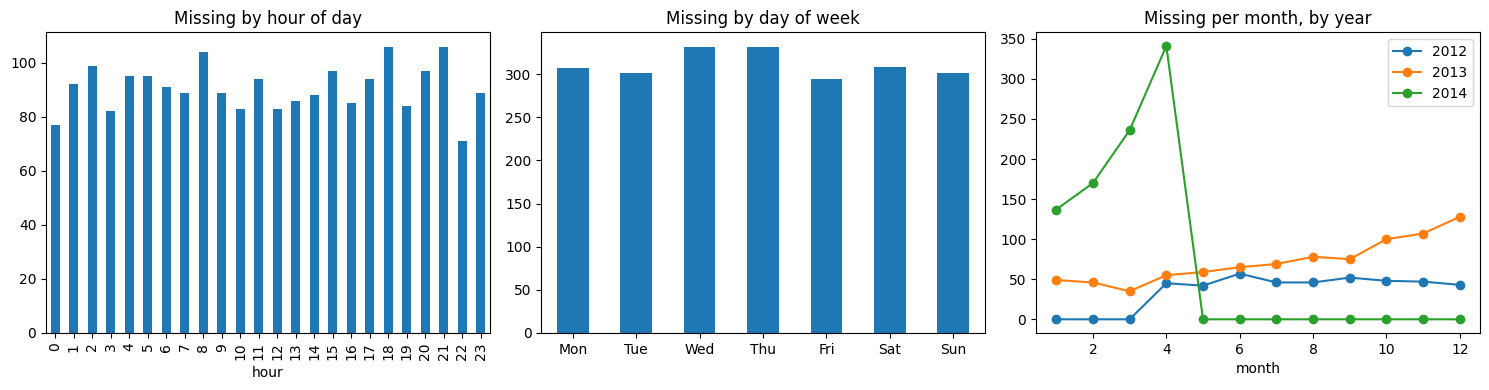

In [18]:
# Missing timestamps (Zone 1 = shared grid): when do they occur?
full = pd.date_range(zones[1].ts.min(), zones[1].ts.max(), freq="1h")
miss = full.difference(zones[1].ts)
print("missing hours:", len(miss))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

pd.Series(miss.hour).value_counts().sort_index().plot.bar(ax=ax[0])
ax[0].set_title("Missing by hour of day"); ax[0].set_xlabel("hour")

pd.Series(miss.dayofweek).value_counts().sort_index().plot.bar(ax=ax[1])
ax[1].set_title("Missing by day of week")
ax[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)

piv = pd.Series(1, miss).groupby([miss.month, miss.year]).size().unstack(fill_value=0)
piv.plot(marker="o", ax=ax[2]); ax[2].set_title("Missing per month, by year"); ax[2].set_xlabel("month")

plt.tight_layout(); plt.show()


## Data preprocessing